# ADMET-Guided Molecule Generation

> ### In this tutorial we will cover:
> - Building a small medicinal-chemistry fragment library
> - Defining a multi-objective ADMET scoring function with `admet-ai`
> - Using the `Generator` class with multiple search strategies (random, genetic, particle swarm)

In this tutorial we combine BuildAMol's fragment assembler with the `admet-ai` library — which provides pretrained ChemProp models for ~40 ADMET endpoints directly from SMILES — to build a small automated pipeline to build potential candidate molecules, *score* them on ADMET properties and use that score to guide the search towards better candidates.

As always, this is a toy example rather than a production tool. The fragment library is intentionally small, the step counts are modest, and the scoring function is simplified. The point is to show the building blocks so you can scale up to your own use case.

With that said, let's dive in!

## Building a Fragment Library

First, we need a set of fragments to assemble molecules from. Good drug-like molecules are typically built from a palette of aromatic rings, saturated heterocycles, and small polar functional groups — the same kinds of motifs that medicinal chemists reach for when elaborating a scaffold. Let's define a small but representative set.

In [1]:
import buildamol as bam
import numpy as np

# Aromatic carbocycles
benzene    = bam.Molecule.from_smiles("c1ccccc1",       id="BNZ").autolabel()
naphthalene= bam.Molecule.from_smiles("c1ccc2ccccc2c1", id="NAP").autolabel()

# N-heteroaromatics
pyridine   = bam.Molecule.from_smiles("c1ccncc1",       id="PYR").autolabel()
pyrimidine = bam.Molecule.from_smiles("c1cnc(cn1)C",    id="PRM").autolabel()

# O/S-heteroaromatics
furan      = bam.Molecule.from_smiles("c1ccoc1",        id="FUR").autolabel()
thiophene  = bam.Molecule.from_smiles("c1ccsc1",        id="THI").autolabel()

# Saturated N-heterocycles (improve solubility and bioavailability)
piperidine = bam.Molecule.from_smiles("C1CCNCC1",       id="PIP").autolabel()
morpholine = bam.Molecule.from_smiles("C1COCCN1",       id="MOR").autolabel()
piperazine = bam.Molecule.from_smiles("C1CNCCN1",       id="PZN").autolabel()

# Functional group fragments
phenol     = bam.Molecule.from_smiles("Oc1ccccc1",      id="PHN").autolabel()
aniline    = bam.Molecule.from_smiles("Nc1ccccc1",      id="ANL").autolabel()
acetamide  = bam.Molecule.from_smiles("CC(=O)N",        id="ACM").autolabel()

fragments = [
    benzene, naphthalene, pyridine, pyrimidine,
    furan, thiophene,
    piperidine, morpholine, piperazine,
    phenol, aniline, acetamide,
]
print(f"Fragment library: {len(fragments)} fragments")

Fragment library: 12 fragments


We can have a quick look at a few of them to confirm they look right:

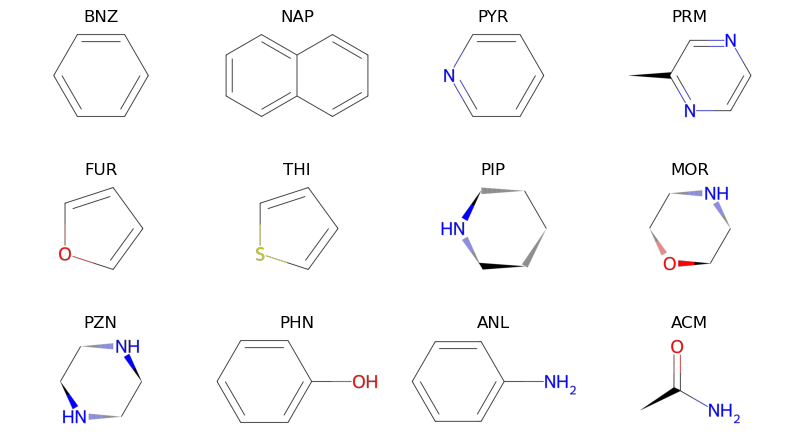

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 4, figsize=(8, 5))
for frag, ax in zip(fragments, axs.flat):
    ax.imshow(frag.draw2d().draw(linewidth=4, fontsize=100))
    ax.set_title(frag.id)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Defining an ADMET Scoring Function

We'll use [`admet-ai`](https://github.com/swansonk14/admet_ai) to evaluate each candidate molecule. Under the hood it runs a small ensemble of ChemProp message-passing neural networks trained on curated ADMET benchmark datasets — all from a SMILES string, no 3D coordinates needed.

Let's explore what the model returns for a single molecule before wiring it into the Generator:

In [ ]:
from admet_ai import ADMETModel

admet_model = ADMETModel()

test_smiles = "Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1"
preds = admet_model.predict(smiles=test_smiles)

# print a selection of the ~85 available properties
keys_of_interest = [
    "HIA_Hou",          # human intestinal absorption   [0 = poor, 1 = good]
    "Bioavailability_Ma",  # oral bioavailability          [0 = poor, 1 = good]
    "hERG",             # hERG channel inhibition risk  [0 = safe, 1 = risky]
    "AMES",             # Ames mutagenicity             [0 = safe, 1 = mutagenic]
    "ClinTox",          # clinical toxicity             [0 = safe, 1 = toxic]
    "Solubility_AqSolDB",  # aqueous solubility (log mol/L) — higher is more soluble
    "QED",              # quantitative estimate of drug-likeness [0-1]
]
for k in keys_of_interest:
    print(f"  {k:<28}  {preds[k]:.3f}")

model ensembles:   0%|          | 0/2 [00:00<?, ?it/s]









individual models: 100%|██████████| 5/5 [00:00<00:00, 144.46it/s]










model ensembles: 100%|██████████| 2/2 [00:00<00:00, 26.76it/s]


  HIA_Hou                       0.966
  Bioavailability_Ma            0.860
  hERG                          0.952
  AMES                          0.263
  ClinTox                       0.637
  Solubility_AqSolDB            -2.557
  QED                           0.939


Now we can define our scoring function. The Generator expects a function `scoring_fn(mol) -> float`, so any conversion to SMILES (or anything else) lives inside the function itself.

We'll use a simple multi-objective composite that rewards good absorption and bioavailability while penalising cardiac toxicity (hERG) and mutagenicity (AMES):

$$\text{score} = \text{HIA} + \text{Bioavailability} - \text{hERG} - \text{AMES}$$

All four terms are probabilities in $[0, 1]$, so the theoretical range is $[-2, +2]$ — higher is better. Feel free to swap in different endpoints or weights depending on your target profile.

In [ ]:
import contextlib
import io

# because the predict method by default prints out a lot of additional information
# we wrap it to surpress the output, so that it doesn't clutter the notebook
if not hasattr(admet_model, "_original_predict"):
    admet_model._original_predict = admet_model.predict

def _quiet_predict(*args, **kwargs):
    with (
        contextlib.redirect_stdout(io.StringIO()),
        contextlib.redirect_stderr(io.StringIO()),
    ):
        return admet_model._original_predict(*args, **kwargs)

admet_model.predict = _quiet_predict

def admet_score(mol):
    preds = admet_model.predict(smiles=mol.to_smiles())
    absorption     = preds["HIA_Hou"]           # maximize
    bioavailability= preds["Bioavailability_Ma"] # maximize
    herg           = preds["hERG"]               # minimize (penalty)
    ames           = preds["AMES"]               # minimize (penalty)
    return absorption + bioavailability - herg - ames

## Setting up the Generator

Alright, now that we have both a fragment library and a scoring function, we only need to combine them into a pipeline. We can do so using the `Generator` class, which wraps an `Assembler` with the scoring function and a search loop. We tell it how many fragments to chain together per molecule and that we want to *maximise* the score, then we're ready to run.

In [33]:
from buildamol.extensions.molecular_factories import Generator

gen = Generator(
    fragments=fragments,
    scoring_fn=admet_score,
    n_fragments=3,
    maximize=True,
)

## Searching for Good Candidates

The `Generator` supports multiple search strategies, including `random`, `PSO`, `genetic`, or any algorithm supported by `scipy.optimize`. The search runs are cumulative, meaning we can run multiple rounds of searching with different algorithms to perform a multi-step optimisation, going from coarse-grained space exploration to promising candidate fine-tuning.

To illustrate a possible workflow, let's go with a "random pre-search" followed by a "genetic finetuning".

### Step 1 — Random baseline

Random search is by far the cheapest strategy: just sample random assemblies and score them. On a small fragment library like this one it already covers a decent portion of the space, and it gives us a baseline to compare the guided methods against. Here's how to run it:

Top 3 after random search:
  score=1.830  Cc1nccnc1CC(=O)Nc1ccoc1
  score=1.816  O=C(CCc1cnccn1)Nc1ccccc1
  score=1.811  NC(=O)CCC(=O)Nc1ccncc1


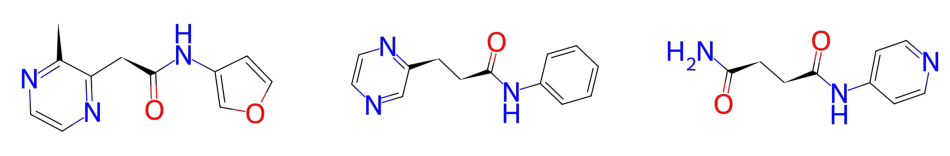

In [ ]:
gen.run(n_steps=500, method="random")

top_k = 3
top_random = gen.top(top_k)
print(f"Top {top_k} after random search:")
fig, axs = plt.subplots(1, top_k, figsize=(12, 4))
for i, r in enumerate(top_random):
    print(f"  score={r['score']:.3f}  {r['molecule'].to_smiles()}")
    axs[i].imshow(r['molecule'].draw2d().draw(linewidth=4, fontsize=100))
    axs[i].axis('off')

### Step 2 — Guided search (genetic)

Random search treats every candidate independently. A genetic algorithm instead maintains a *population* of instruction matrices, uses the best ones as parents for the next generation, and gradually improves the population through selection, crossover, and mutation. 

Because `run()` accumulates all results across calls, we can chain methods and let each strategy build on what the others already found:

Total valid molecules evaluated: 919

Overall top 3:
  score=1.849  O=C(CCc1cnccn1)Nc1ccoc1
  score=1.830  Cc1nccnc1CC(=O)Nc1ccoc1
  score=1.828  NC(=O)Cc1ccc(-c2ccncc2)cn1


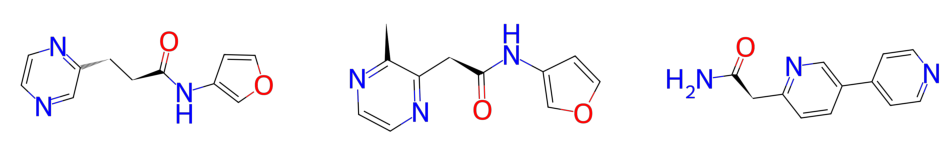

In [ ]:
gen.run(n_steps=50, method="genetic", population_size=50, mutation_rate=0.15)

print(f"Total valid molecules evaluated: {len(gen.to_dataframe())}")
top_k = 3
print(f"\nOverall top {top_k}:")
fig, axs = plt.subplots(1, top_k, figsize=(12, 4))
for i, r in enumerate(gen.top(top_k)):
    print(f"  score={r['score']:.3f}  {r['molecule'].to_smiles()}")
    axs[i].imshow(r['molecule'].draw2d().draw(linewidth=4, fontsize=100))
    axs[i].axis('off')

## Inspecting the Results

Let's look at the score distribution across all evaluated molecules and then draw the top candidates.

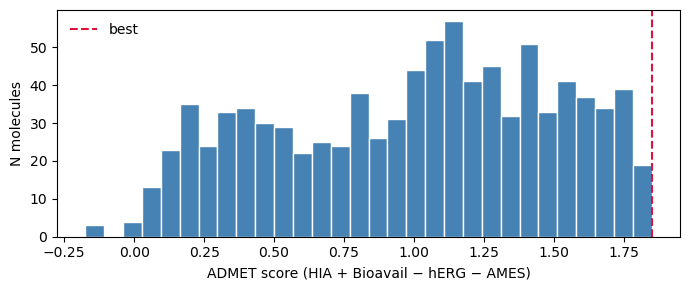

Score range: -0.175 – 1.849


In [43]:
import pandas as pd

df = gen.to_dataframe()

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(df["score"], bins=30, color="steelblue", edgecolor="white")
ax.axvline(df["score"].max(), color="crimson", linestyle="--", label="best")
ax.set_xlabel("ADMET score (HIA + Bioavail − hERG − AMES)")
ax.set_ylabel("N molecules")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Score range: {df['score'].min():.3f} – {df['score'].max():.3f}")

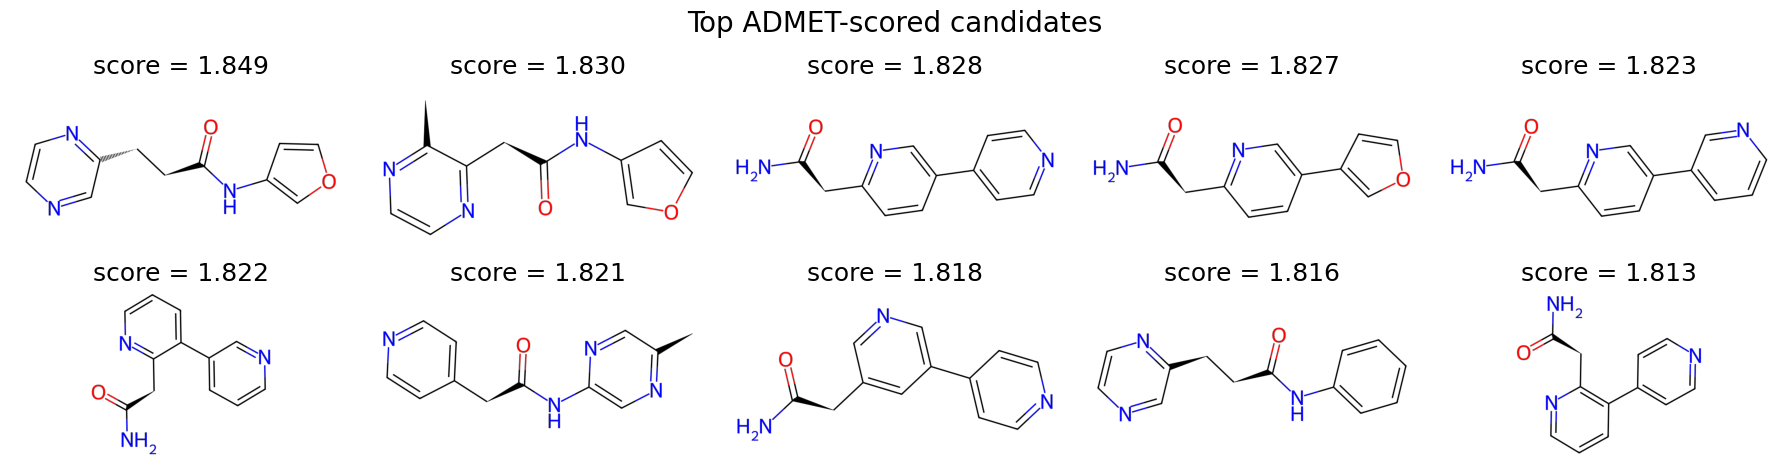

In [41]:
top5 = gen.top(10)

fig, axs = plt.subplots(2, 5, figsize=(18, 5))
for r, ax in zip(top5, axs.flat):
    ax.imshow(r["molecule"].draw2d().draw(linewidth=4, fontsize=60))
    ax.set_title(f"score = {r['score']:.3f}", fontsize=18)
    ax.axis("off")
plt.suptitle("Top ADMET-scored candidates", fontsize=20)
plt.tight_layout()
plt.show()

## Breaking Down the Score

Because the scoring function is just a Python function, we can call `admet_model.predict` on any candidate and inspect the individual contributions to the composite score. Let's do that for the best molecule:

In [42]:
best_mol  = gen.best
best_smiles = best_mol.to_smiles()
props = admet_model.predict(smiles=best_smiles)

report = {
    "HIA (absorption)": props["HIA_Hou"],
    "Bioavailability":  props["Bioavailability_Ma"],
    "hERG risk":        props["hERG"],
    "AMES risk":        props["AMES"],
    "QED":              props["QED"],
    "Solubility (logS)": props["Solubility_AqSolDB"],
    "Lipinski pass":    props["Lipinski"],
}
print(f"Best molecule: {best_smiles}\n")
for k, v in report.items():
    print(f"  {k:<25} {v:.3f}")

Best molecule: O=C(CCc1cnccn1)Nc1ccoc1

  HIA (absorption)          1.000
  Bioavailability           0.947
  hERG risk                 0.020
  AMES risk                 0.078
  QED                       0.845
  Solubility (logS)         -1.454
  Lipinski pass             4.000


## Customising the Search

The `Generator` is intentionally general. A few things worth knowing:

**Scoring function** — the only contract is `fn(mol) -> float`. You can use any library, combine as many properties as you like, or wrap a docking call (as in the docking tutorial) to optimise binding affinity instead of ADMET.

**Chaining strategies** — results accumulate across `run()` calls so you can use random search as a warm-start for the guided methods:

```python
gen = Generator(fragments, my_score_fn, n_fragments=4)
gen.run(200, method="random")             # broad exploration first
gen.run(50,  method="genetic")            # refine with evolution
gen.run(30,  method="swarm", n_particles=20)  # fine-tune with PSO
```

**scipy methods** — `method="scipy"` hands the problem to `scipy.optimize.minimize`. Any method that doesn't require gradients (Nelder-Mead, COBYLA, Powell) works with the integer matrix encoding:

```python
gen.run(100, method="scipy", scipy_method="Powell")
```

**Fragment library size** — a larger, more chemically diverse library (e.g. from the Fragment Library tutorial) combined with more steps will produce a much wider range of candidates. The library here is intentionally minimal to keep the tutorial fast.


And that's it for this time! With a fragment library, a scoring function, and a few lines of `Generator` API, we have a configurable molecule generation pipeline. Thanks a lot for checking out this tutorial and good luck with your project using BuildAMol!


And that's it for this time! With a fragment library, a scoring function, and a few lines of `Generator` API, we have a configurable molecule generation pipeline. Thanks a lot for checking out this tutorial and good luck with your project using BuildAMol!